In [5]:
import cu_rsc as cr
cr.setup_tables()
import numpy as np
import cupy as cp
import cupyx
import matplotlib.pyplot as plt
from cycler import cycler
from typing import Tuple, List
plt.style.use("aps.mplstyle")
import matplotlib as mpl
mpl.rcParams['axes.prop_cycle'] = cycler(
    'color',
    ['#1b9e77', '#d95f02', '#7570b3', '#e7298a',
     '#66a61e', '#e6ab02', '#a6761d', '#666666']
)
M_dev = cr.load_m_table_device()        # upload to GPU
res   = cr.resources_from_config(M_dev)

In [2]:
def score_molecules(
    mol: cp.ndarray,
    *,
    max_nz: int = 10,
) -> Tuple[int, float, float]:
    
    if mol.ndim != 2 or mol.shape[1] < 6:
        raise ValueError("mol must be shape (N,6)")

    n_x = mol[:, 0]
    n_y = mol[:, 1]
    n_z = mol[:, 2]
    mN  = mol[:, 3]
    spin = mol[:, 4]
    is_lost = mol[:, 5]

    N = int(mol.shape[0])

    # Define survivors in the correct manifold
    survived = (mN == 1) & (spin == 0) & (is_lost == 0)
    surv_count = int(cp.count_nonzero(survived).get())

    # Score: nx==0, ny==0, nz <= max_nz, and survived
    meet_n_condition = (n_x == 0) & (n_y == 0) & (n_z <= int(max_nz))
    good_mask = survived & meet_n_condition

    score_count = int(cp.count_nonzero(good_mask).get())
    good_fraction = float(surv_count / N) if N > 0 else 0.0

    # nz_bar: mean nz among survived (correct manifold). nan if none.
    surv_count = int(cp.count_nonzero(survived).get())
    if surv_count > 0:
        nz_sum = cp.sum(n_z[survived]).astype(cp.float64)
        nz_bar = float((nz_sum / float(surv_count)).get())
    else:
        nz_bar = float("nan")

    return score_count, good_fraction, nz_bar

### Further optimization

#### First, optimize $\Omega$ and $t$ for $n_z\le 10$ with the guessed sequence

In [6]:
seq_op = np.load("../new_sequence_optimization/op_amp_time/omega_time_ga_runs/OmegaTimeGA_20260619_085100/final_top5/top1_sequence.npy")
print(np.unique(seq_op, axis=0))

[[ 0.00000000e+00 -3.00000000e+00  1.56730548e+04  7.85930082e-05]
 [ 0.00000000e+00 -2.00000000e+00  2.34496927e+04  5.63646032e-05]
 [ 0.00000000e+00 -1.00000000e+00  7.48812730e+03  1.39329896e-04]
 [ 1.00000000e+00 -3.00000000e+00  1.44362668e+04  9.61245952e-05]
 [ 1.00000000e+00 -2.00000000e+00  1.05955053e+04  1.03914104e-04]
 [ 1.00000000e+00 -1.00000000e+00  6.34140113e+03  1.23213536e-04]
 [ 2.00000000e+00 -1.00000000e+01  7.15151232e+03  4.69568342e-05]
 [ 2.00000000e+00 -9.00000000e+00  2.92950254e+04  4.83842394e-05]
 [ 2.00000000e+00 -8.00000000e+00  1.61810508e+04  5.93758388e-05]
 [ 2.00000000e+00 -7.00000000e+00  5.23012355e+03  3.08082445e-05]
 [ 2.00000000e+00 -6.00000000e+00  1.47754140e+04  8.71598322e-05]
 [ 2.00000000e+00 -5.00000000e+00  1.17629288e+04  1.88233289e-04]
 [ 2.00000000e+00 -4.00000000e+00  3.26483548e+03  1.39606891e-04]
 [ 2.00000000e+00 -3.00000000e+00  6.16795738e+00  7.20861942e-05]
 [ 2.00000000e+00 -2.00000000e+00  1.77210450e+03  1.41012932e

Raman pulses: 100%|██████████| 260/260 [01:05<00:00,  3.98it/s]
/n/home02/lyuqinshu/cu_rsc/src/cu_rsc/analysis.py:84: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


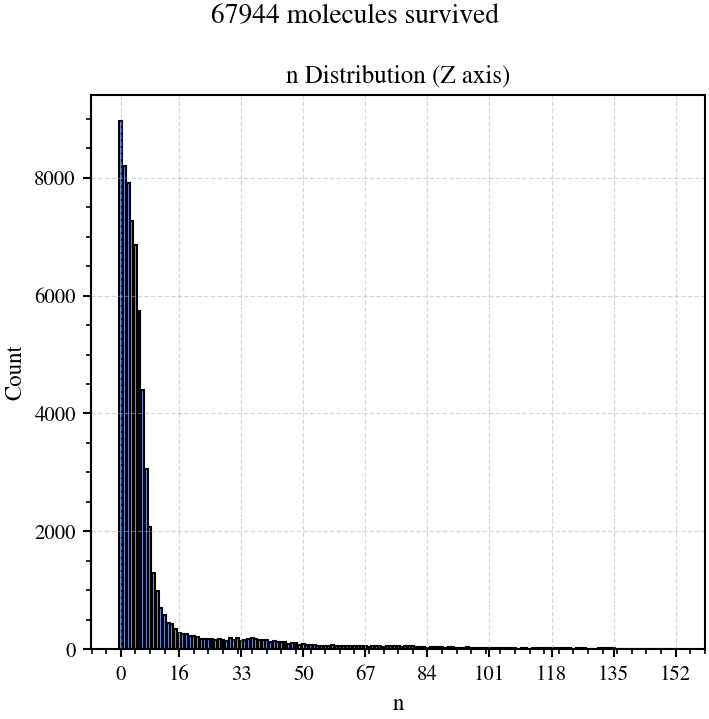

51463
Fraction of good molecules =  0.51463


In [16]:
temp = [25e-6, 25e-6, 25e-6]
mol_num = 100000
trap_detuning_sigma = 0.5e3
carrier_detuning_sigma = 0.0e3
mol_op = cr.build_thermal_molecules(mol_num, temp, 
                                     trap_detuning_sigma=trap_detuning_sigma, 
                                     carrier_detuning_sigma=carrier_detuning_sigma)
cr.raman_cool_with_pumping(mol_op, seq_op, res, show_progress=True)
dist_op = cr.get_n_distribution_gpu(mol_op, max_bins=10, plot=(False, False, True))
result_op = cr.bootstrap_stats_from_molecules(mol_op)
print(score_molecules(mol_op)[0])
print("Fraction of good molecules = ", score_molecules(mol_op)[0]/mol_num)

### Remove $\Delta n\ge -3$

In [7]:
mask = ~((seq_op[:, 0] == 2) & (seq_op[:, 1] >= -3))
seq_1 = seq_op[mask]
seq_1.shape

(212, 4)

Raman pulses: 100%|██████████| 212/212 [00:57<00:00,  3.71it/s]


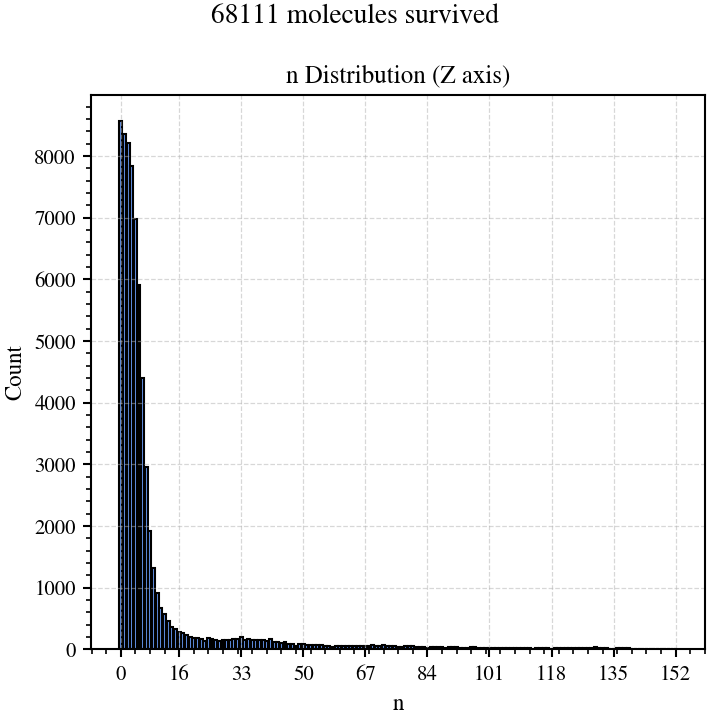

52304
Fraction of good molecules =  0.52304


In [20]:
temp = [25e-6, 25e-6, 25e-6]
mol_num = 100000
trap_detuning_sigma = 0.5e3
carrier_detuning_sigma = 0.0e3
mol_op = cr.build_thermal_molecules(mol_num, temp, 
                                     trap_detuning_sigma=trap_detuning_sigma, 
                                     carrier_detuning_sigma=carrier_detuning_sigma)
cr.raman_cool_with_pumping(mol_op, seq_1, res, show_progress=True)
dist_op = cr.get_n_distribution_gpu(mol_op, max_bins=10, plot=(False, False, True))
result_op = cr.bootstrap_stats_from_molecules(mol_op)
print(score_molecules(mol_op)[0])
print("Fraction of good molecules = ", score_molecules(mol_op)[0]/mol_num)

### Rready sequence for order optimization

In [6]:
# ==============================
# Reverse engineering helpers
# ==============================

def rows_to_indices(seq_cap: np.ndarray, seq_list: np.ndarray, atol=1e-12, rtol=1e-9) -> np.ndarray:
    seq_cap = np.asarray(seq_cap, dtype=float)
    seq_list = np.asarray(seq_list, dtype=float)

    indices = []
    for row in seq_cap:
        matches = np.where(np.all(np.isclose(seq_list, row, atol=atol, rtol=rtol), axis=1))[0]
        if len(matches) == 0:
            raise ValueError(f"No match found in seq_list for row:\n{row}")
        if len(matches) > 1:
            raise ValueError(f"Ambiguous match for row:\n{row}\nMatches: {matches}")
        indices.append(int(matches[0]))
    return np.array(indices, dtype=int)


def compress_indices_to_blocks(indices: np.ndarray) -> List[Tuple[np.ndarray, int]]:
    """
    Greedy compression into repeated contiguous blocks.
    """
    indices = np.asarray(indices, dtype=int)
    n = len(indices)
    out: List[Tuple[np.ndarray, int]] = []

    i = 0
    while i < n:
        best_pattern = None
        best_repeats = 1
        best_score = 1

        max_pat_len = (n - i) // 2
        for pat_len in range(1, max_pat_len + 1):
            pattern = indices[i:i + pat_len]
            repeats = 1

            while i + (repeats + 1) * pat_len <= n:
                nxt = indices[i + repeats * pat_len : i + (repeats + 1) * pat_len]
                if np.array_equal(nxt, pattern):
                    repeats += 1
                else:
                    break

            score = pat_len * repeats
            if repeats > 1 and score > best_score:
                best_pattern = pattern.copy()
                best_repeats = repeats
                best_score = score

        if best_pattern is not None:
            out.append((best_pattern, best_repeats))
            i += len(best_pattern) * best_repeats
        else:
            out.append((np.array([indices[i]], dtype=int), 1))
            i += 1

    return out


def reverse_engineer_blocks(
    seed_seq: np.ndarray,
    seq_list: np.ndarray,
    atol=1e-12,
    rtol=1e-9,
) -> Tuple[np.ndarray, List[Tuple[np.ndarray, int]]]:
    idx = rows_to_indices(seed_seq, seq_list, atol=atol, rtol=rtol)
    block_specs = compress_indices_to_blocks(idx)
    return idx, block_specs

In [8]:
seq_trim = np.delete(seq_1, np.s_[74:80], axis=0)
seq_list = np.unique(seq_1, axis=0)

In [9]:
i, blocks = reverse_engineer_blocks(seq_trim, seq_list)

In [37]:
blocks

[(array([6, 7, 8, 9]), 6),
 (array([0, 6, 7, 8, 9, 3, 6, 7, 8, 9]), 5),
 (array([ 8,  9, 10, 11,  1,  8,  9, 10, 11,  4]), 6),
 (array([10, 11, 12,  2, 10, 11, 12,  5]), 6),
 (array([12,  2, 12,  5]), 6)]

In [12]:
np.save("seq_0622.npy", seq_trim)
np.save("seq_list_0622.npy", seq_list)

In [ ]:
%run ../new_sequence_optimization/op_pulse_order/op_order.py

### Optimized order

In [18]:
seq_op = np.load("../new_sequence_optimization/op_pulse_order/block_varlen_ga_runs/BlockVarLenGA_20260622_085905/final_top5/top1_sequence.npy")
seq_op_list = np.unique(seq_op, axis=0)

Raman pulses: 100%|██████████| 163/163 [00:44<00:00,  3.65it/s]
/n/home02/lyuqinshu/cu_rsc/src/cu_rsc/analysis.py:84: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


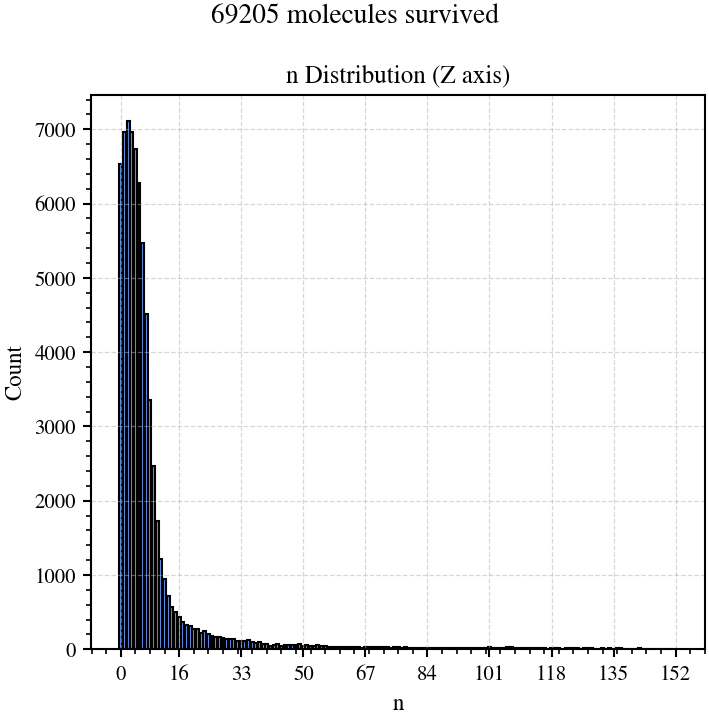

55752
Fraction of good molecules =  0.55752


In [7]:
temp = [25e-6, 25e-6, 25e-6]
mol_num = 100000
trap_detuning_sigma = 0.5e3
carrier_detuning_sigma = 0.0e3
mol_op = cr.build_thermal_molecules(mol_num, temp, 
                                     trap_detuning_sigma=trap_detuning_sigma, 
                                     carrier_detuning_sigma=carrier_detuning_sigma)
cr.raman_cool_with_pumping(mol_op, seq_op, res, show_progress=True)
dist_op = cr.get_n_distribution_gpu(mol_op, max_bins=10, plot=(False, False, True))
result_op = cr.bootstrap_stats_from_molecules(mol_op)
print(score_molecules(mol_op)[0])
print("Fraction of good molecules = ", score_molecules(mol_op)[0]/mol_num)

### Trim

In [20]:
i, blocks = reverse_engineer_blocks(seq_op, seq_op_list)
blocks

[(array([3]), 2),
 (array([8]), 1),
 (array([ 0,  0,  7,  9, 11,  6,  7,  3,  3]), 7),
 (array([ 8,  8,  9, 10,  1,  3,  4,  5,  1,  6,  9,  0]), 4),
 (array([ 9,  5, 10,  9,  8,  5,  2]), 6),
 (array([8]), 1),
 (array([2]), 1),
 (array([10]), 1),
 (array([4]), 1),
 (array([5]), 1),
 (array([0]), 1),
 (array([5]), 1)]

In [22]:
seq_op_trim = seq_op[3:-7]
i, blocks = reverse_engineer_blocks(seq_op_trim, seq_op_list)
blocks

[(array([ 0,  0,  7,  9, 11,  6,  7,  3,  3]), 7),
 (array([ 8,  8,  9, 10,  1,  3,  4,  5,  1,  6,  9,  0]), 4),
 (array([ 9,  5, 10,  9,  8,  5,  2]), 6)]

Raman pulses: 100%|██████████| 153/153 [00:41<00:00,  3.73it/s]
/n/home02/lyuqinshu/cu_rsc/src/cu_rsc/analysis.py:84: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


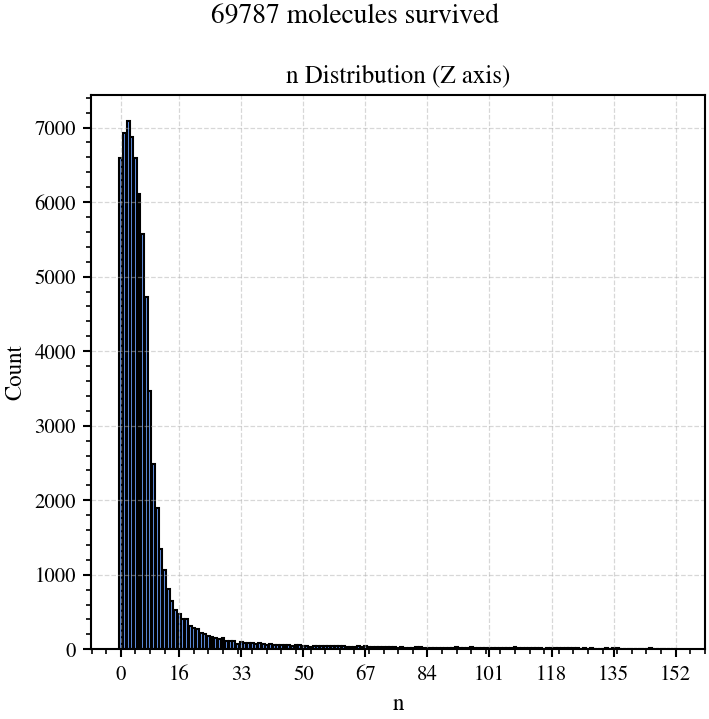

55174
Fraction of good molecules =  0.55174


In [23]:
temp = [25e-6, 25e-6, 25e-6]
mol_num = 100000
trap_detuning_sigma = 0.5e3
carrier_detuning_sigma = 0.0e3
mol_op = cr.build_thermal_molecules(mol_num, temp, 
                                     trap_detuning_sigma=trap_detuning_sigma, 
                                     carrier_detuning_sigma=carrier_detuning_sigma)
cr.raman_cool_with_pumping(mol_op, seq_op_trim, res, show_progress=True)
dist_op = cr.get_n_distribution_gpu(mol_op, max_bins=10, plot=(False, False, True))
result_op = cr.bootstrap_stats_from_molecules(mol_op)
print(score_molecules(mol_op)[0])
print("Fraction of good molecules = ", score_molecules(mol_op)[0]/mol_num)

### Compare to optimization used in dipole interaction

In [11]:
temp = [25e-6, 25e-6, 25e-6]
mol_ref = cr.build_thermal_molecules(100000, temp, 
                                     trap_detuning_sigma=trap_detuning_sigma,
                                    carrier_detuning_sigma=carrier_detuning_sigma)
dist_ref = cr.get_n_distribution_gpu(mol_ref, max_bins=10, plot=(False, False, False))

Raman pulses: 100%|██████████| 140/140 [00:37<00:00,  3.71it/s]


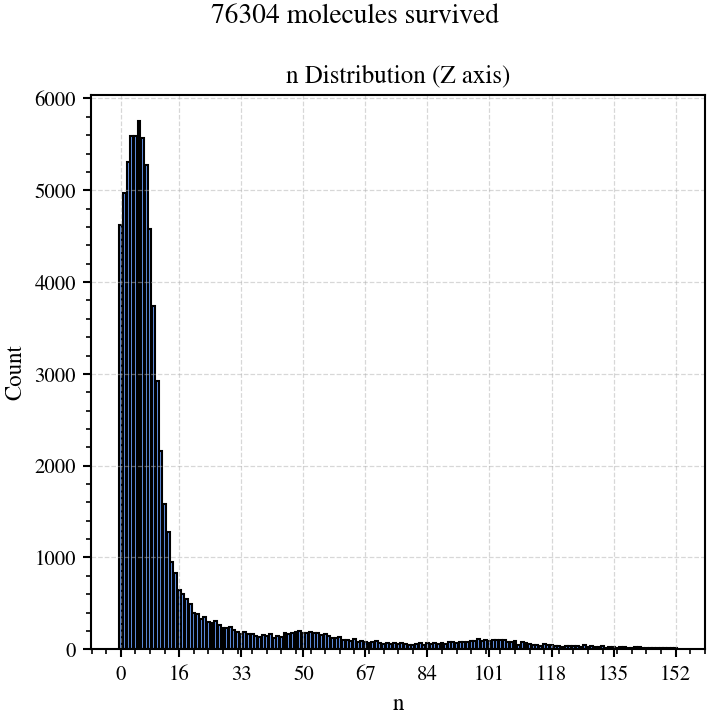

In [10]:
seq_exp = np.load("runs/seq_cap_0406.npy")[:140]
temp = [25e-6, 25e-6, 25e-6]
trap_detuning_sigma = 0.5e3
carrier_detuning_sigma = 0.0e3
mol_exp = cr.build_thermal_molecules(100000, temp, 
                                     trap_detuning_sigma=trap_detuning_sigma, 
                                     carrier_detuning_sigma=carrier_detuning_sigma)
cr.raman_cool_with_pumping(mol_exp, seq_exp, res, show_progress=True)
dist_exp = cr.get_n_distribution_gpu(mol_exp, max_bins=10, plot=(False, False, True))
result_exp = cr.bootstrap_stats_from_molecules(mol_exp)

In [24]:
import numpy as np
from scipy.interpolate import interp1d

def get_axis_distribution(dist_exp, dist_ref, dist_op, axis, n_points=500):
    data_exp = dist_exp[axis]
    data_ref = dist_ref[axis]
    data_op  = dist_op[axis]

    x_exp = np.array(sorted(data_exp.keys()))
    y_exp = np.array([data_exp[k] for k in x_exp], dtype=float)

    x_ref = np.array(sorted(data_ref.keys()))
    y_ref = np.array([data_ref[k] for k in x_ref], dtype=float)

    x_op = np.array(sorted(data_op.keys()))
    y_op = np.array([data_op[k] for k in x_op], dtype=float)

    y_exp /= y_exp.sum()
    y_ref /= y_ref.sum()
    y_op  /= y_op.sum()

    f_exp = interp1d(x_exp, y_exp, kind="linear", fill_value="extrapolate")
    f_ref = interp1d(x_ref, y_ref, kind="linear", fill_value="extrapolate")
    f_op  = interp1d(x_op,  y_op,  kind="linear", fill_value="extrapolate")

    x_min = min(x_exp.min(), x_ref.min(), x_op.min())
    x_max = max(x_exp.max(), x_ref.max(), x_op.max())

    x_dense = np.linspace(x_min, x_max, n_points)

    y_exp_smooth = np.clip(f_exp(x_dense), 0, None)
    y_ref_smooth = np.clip(f_ref(x_dense), 0, None)
    y_op_smooth  = np.clip(f_op(x_dense), 0, None)

    return x_dense, y_exp_smooth, y_ref_smooth, y_op_smooth


# Get x, y, z axes
axis_results = [
    get_axis_distribution(dist_exp, dist_ref, dist_op, axis)
    for axis in range(3)
]

# Stack into 3 × N arrays
x_dense_all = np.array([r[0] for r in axis_results])
y_exp_all   = np.array([r[1] for r in axis_results])
y_ref_all   = np.array([r[2] for r in axis_results])
y_op_all    = np.array([r[3] for r in axis_results])

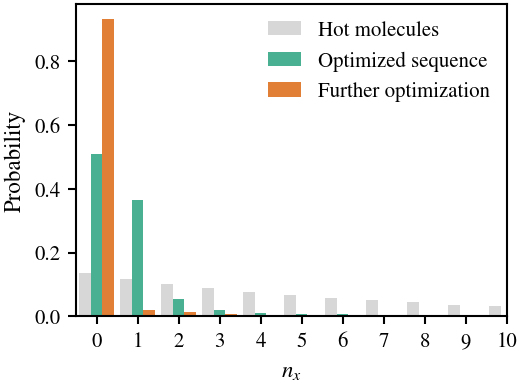

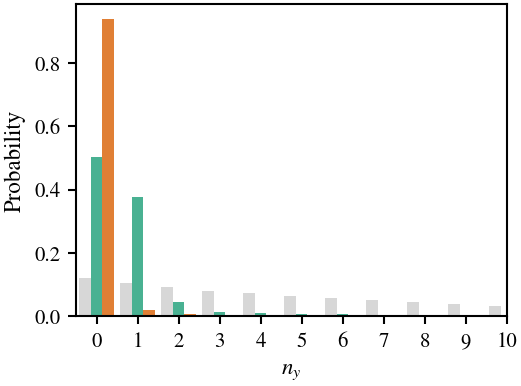

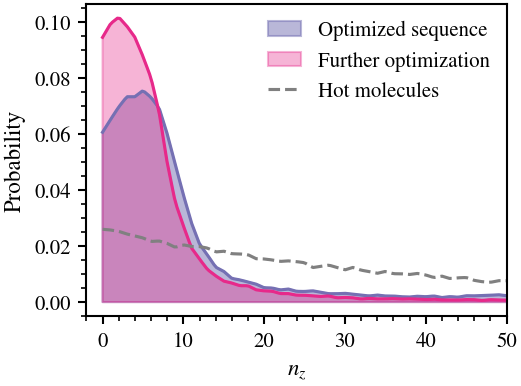

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from matplotlib.ticker import MultipleLocator

axis_labels = [r"$n_x$", r"$n_y$", r"$n_z$"]
axis_names = ["x", "y", "z"]

for axis in range(3):

    # Original distributions
    data_exp = dist_exp[axis]
    data_ref = dist_ref[axis]
    data_op  = dist_op[axis]

    x_exp = np.array(sorted(data_exp.keys()))
    y_exp = np.array([data_exp[k] for k in x_exp], dtype=float)
    y_exp /= y_exp.sum()

    x_ref = np.array(sorted(data_ref.keys()))
    y_ref = np.array([data_ref[k] for k in x_ref], dtype=float)
    y_ref /= y_ref.sum()

    x_op = np.array(sorted(data_op.keys()))
    y_op = np.array([data_op[k] for k in x_op], dtype=float)
    y_op /= y_op.sum()

    plt.figure()

    if axis < 2:

        # Side-by-side bars
        bar_width = 0.28

        plt.bar(
            x_ref - bar_width,
            y_ref,
            width=bar_width,
            color="lightgray",
            alpha=0.9,
            label="Hot molecules",
        )

        plt.bar(
            x_exp,
            y_exp,
            width=bar_width,
            color="C0",
            alpha=0.8,
            label="Optimized sequence",
        )

        plt.bar(
            x_op + bar_width,
            y_op,
            width=bar_width,
            color="C1",
            alpha=0.8,
            label="Further optimization",
        )
        plt.xlim((-0.5, 10))
        ax = plt.gca()
        ax.xaxis.set_major_locator(MultipleLocator(1))
        ax.minorticks_off()

    else:

        x_dense = axis_results[axis][0]
        y_exp_smooth = axis_results[axis][1]
        y_ref_smooth = axis_results[axis][2]
        y_op_smooth  = axis_results[axis][3]

        plt.fill_between(
            x_dense,
            0,
            y_exp_smooth,
            color="C2",
            alpha=0.5,
            label="Optimized sequence",
        )

        plt.plot(
            x_dense,
            y_exp_smooth,
            color="C2",
            linewidth=1.5,
        )

        plt.fill_between(
            x_dense,
            0,
            y_op_smooth,
            color="C3",
            alpha=0.35,
            label="Further optimization",
        )

        plt.plot(
            x_dense,
            y_op_smooth,
            color="C3",
            linewidth=1.5,
        )

        plt.plot(
            x_dense,
            y_ref_smooth,
            "--",
            color="Gray",
            linewidth=1.5,
            label="Hot molecules",
        )

        plt.xlim((-2, 50))

    plt.xlabel(axis_labels[axis])
    plt.ylabel("Probability")
    plt.grid(False)

    if axis == 0 or axis == 2:
        plt.legend(frameon=False)

    plt.savefig(
        f"thesis_plot/distribution_further_{axis_names[axis]}.pdf",
        bbox_inches="tight",
    )

    plt.show()

In [26]:
zt_freqs = cp.linspace(-40e3, 20e3, 1000)
zt_rabi = 1.01e3
zt_pulse = 500e-6
temp = [25e-6, 25e-6, 25e-6]

frequencys, polarizations_exp = cr.raman_sideband_thermometry(
    molecules_dev=mol_exp,
    axis=2,
    frequencys=zt_freqs,
    rabi_freq=zt_rabi,
    pulse_time=zt_pulse,
    res=res,
    k_max=2
)

frequencys, polarizations_op = cr.raman_sideband_thermometry(
    molecules_dev=mol_op,
    axis=2,
    frequencys=zt_freqs,
    rabi_freq=zt_rabi,
    pulse_time=zt_pulse,
    res=res,
    k_max=2
)

Raman thermometry: 100%|██████████| 1000/1000 [00:07<00:00, 139.17it/s]


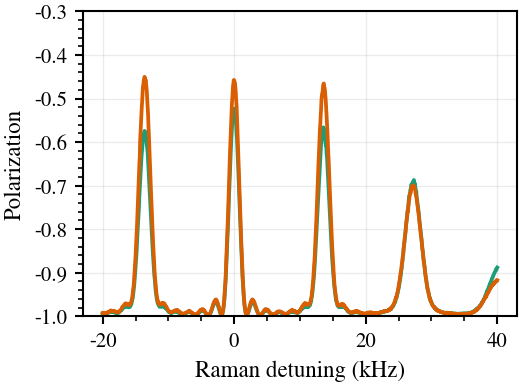

In [27]:
plt.figure()

plt.plot(
    -cp.asnumpy(frequencys*1e-3), 
    cp.asnumpy(polarizations_exp), 
    color='C0',
    label='Optimized sequence'
    )

plt.plot(
    -cp.asnumpy(frequencys*1e-3), 
    cp.asnumpy(polarizations_op), 
    color='C1',
    label='Further optimization'
    )

plt.xlabel("Raman detuning (kHz)")
plt.ylabel("Polarization")
plt.ylim((-1, -0.3))

plt.savefig("RST_comparison.pdf", bbox_inches="tight")

### Print sequence

In [42]:
from matplotlib.ticker import MultipleLocator
def visualize_sequence(seq, show_time_color: bool = False, title: str | None = None, file_name: str | None = None) -> None:
    
    # Convert CuPy → NumPy if needed
    if not isinstance(seq, np.ndarray):
        try:
            import cupy as cp
            if isinstance(seq, cp.ndarray):
                seq = cp.asnumpy(seq)
            else:
                raise TypeError("seq must be a NumPy or CuPy array.")
        except ImportError:
            raise TypeError("seq must be a NumPy array or CuPy array (CuPy not installed).")

    if seq.ndim != 2 or seq.shape[1] not in (3, 4, 5):
        raise ValueError(f"Invalid sequence shape {seq.shape}, expected (P,3), (P,4), or (P,5).")

    P, C = seq.shape
    axes = seq[:, 0].astype(int)
    delta_n = seq[:, 1].astype(int)

    if C == 3:
        times = seq[:, 2].astype(float)
    elif C == 4:
        times = seq[:, 3].astype(float)
    else:  # C == 5
        times = seq[:, 3].astype(float)

    pulse_idx = np.arange(P)

    plt.figure(figsize=(6, 2.5))
    
    if show_time_color:
        sc = plt.scatter(pulse_idx, delta_n, c=times)
        plt.colorbar(sc, label="Pulse duration (s)")
    else:
        colors = {0: "C0", 1: "C1", 2: "C2"}
        labels = {0: "X", 1: "Y", 2: "Z"}
    
        for axv in np.unique(axes):
            mask = axes == axv
            plt.scatter(
                pulse_idx[mask],
                delta_n[mask],
                label=f"{labels.get(axv, axv)}",
                color=colors.get(axv, "gray"),
                s=40,
                alpha=0.9,
                edgecolor="k",
            )
    
        plt.legend(
        frameon=False,
        ncols=3,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        borderaxespad=0.0,
    )
    
    ax = plt.gca()
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.minorticks_off()

    
    plt.ylabel("Δn")
    plt.xlabel("Pulse index")
    plt.grid(True, linestyle="--")
    plt.savefig(
        file_name if file_name is not None else "Raman_Sequence.pdf",
        bbox_inches="tight"
    )
    plt.show()


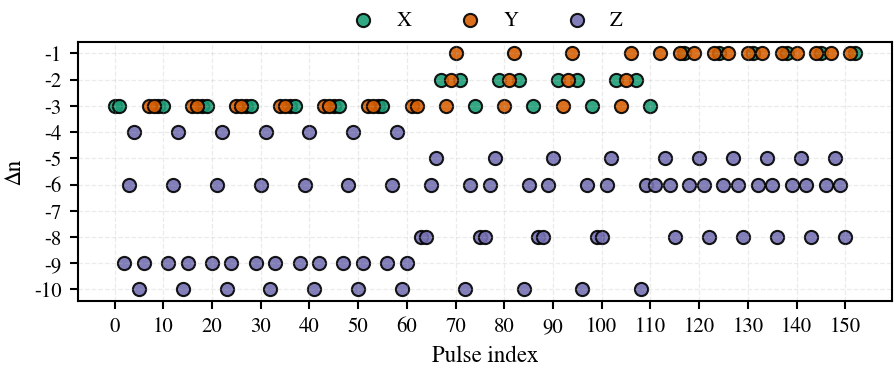

In [43]:
visualize_sequence(seq_op_trim, title="Further optimization", file_name="thesis_plot/futher_op_seq_visualize.pdf")

In [44]:
print(seq_op_list)

[[ 0.00000000e+00 -3.00000000e+00  1.56730548e+04  7.85930082e-05]
 [ 0.00000000e+00 -2.00000000e+00  2.34496927e+04  5.63646032e-05]
 [ 0.00000000e+00 -1.00000000e+00  7.48812730e+03  1.39329896e-04]
 [ 1.00000000e+00 -3.00000000e+00  1.44362668e+04  9.61245952e-05]
 [ 1.00000000e+00 -2.00000000e+00  1.05955053e+04  1.03914104e-04]
 [ 1.00000000e+00 -1.00000000e+00  6.34140113e+03  1.23213536e-04]
 [ 2.00000000e+00 -1.00000000e+01  7.15151232e+03  4.69568342e-05]
 [ 2.00000000e+00 -9.00000000e+00  2.92950254e+04  4.83842394e-05]
 [ 2.00000000e+00 -8.00000000e+00  1.61810508e+04  5.93758388e-05]
 [ 2.00000000e+00 -6.00000000e+00  1.47754140e+04  8.71598322e-05]
 [ 2.00000000e+00 -5.00000000e+00  1.17629288e+04  1.88233289e-04]
 [ 2.00000000e+00 -4.00000000e+00  3.26483548e+03  1.39606891e-04]]
